In [1]:
%pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Starting Housing ML Pipeline
File loaded successfully

Shape: (545, 13)

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate Values: 0

 Datatypes for Each column price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Summary:
     

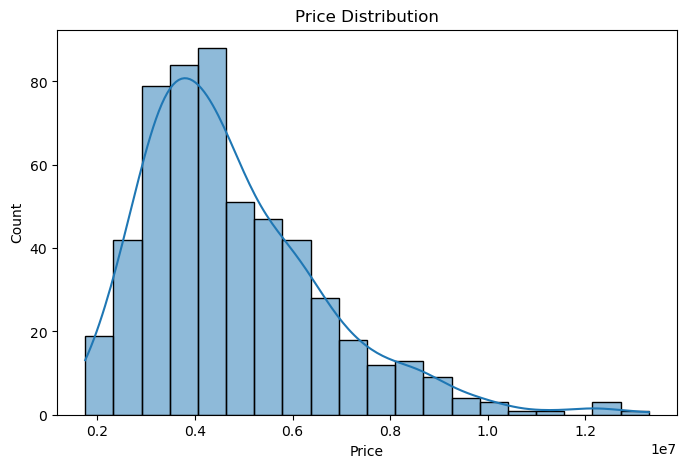

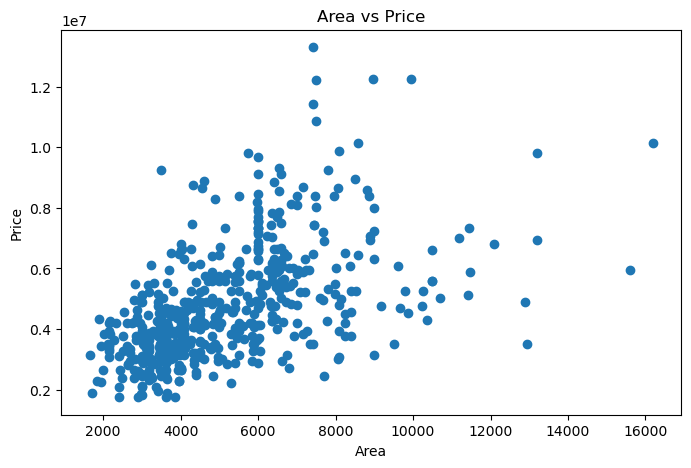

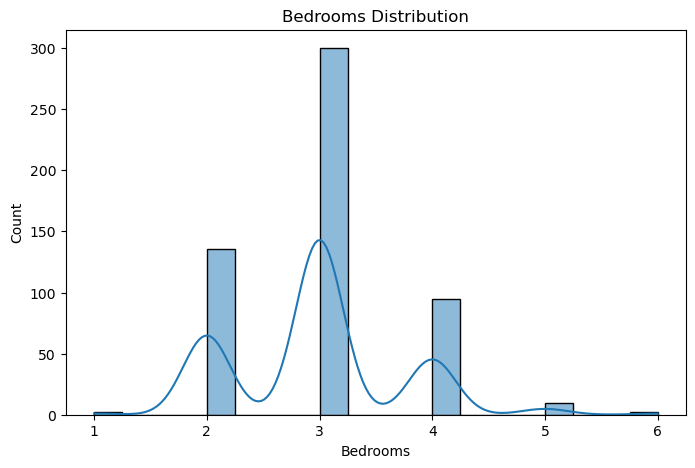

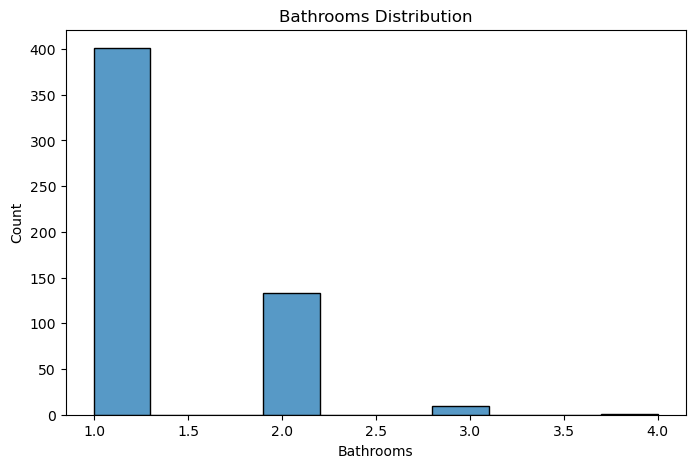

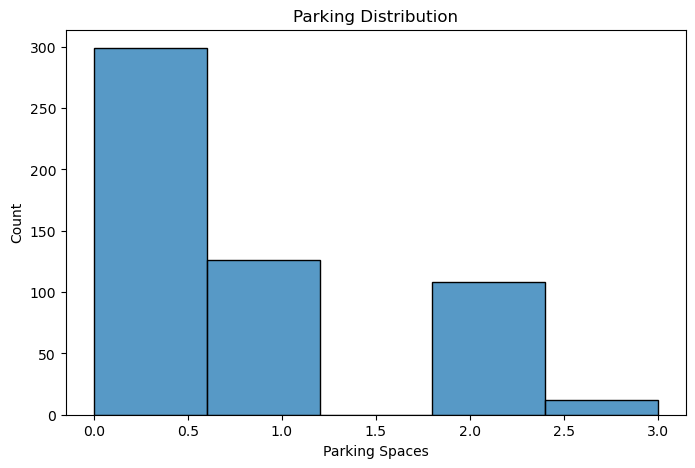

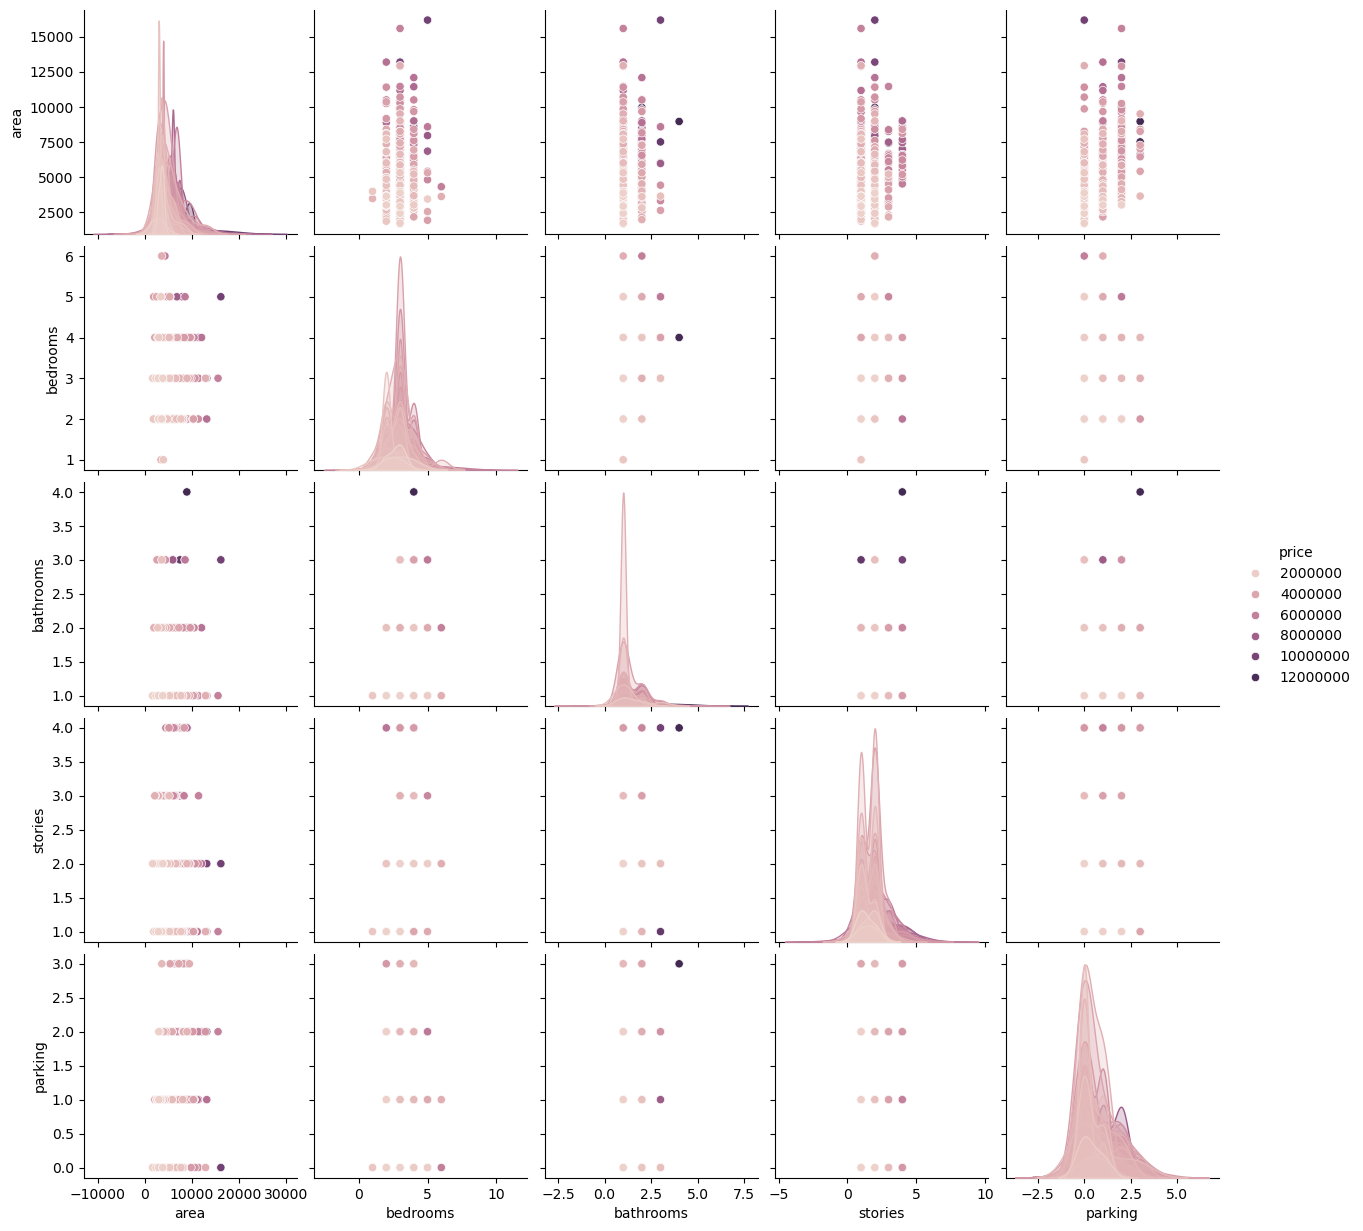

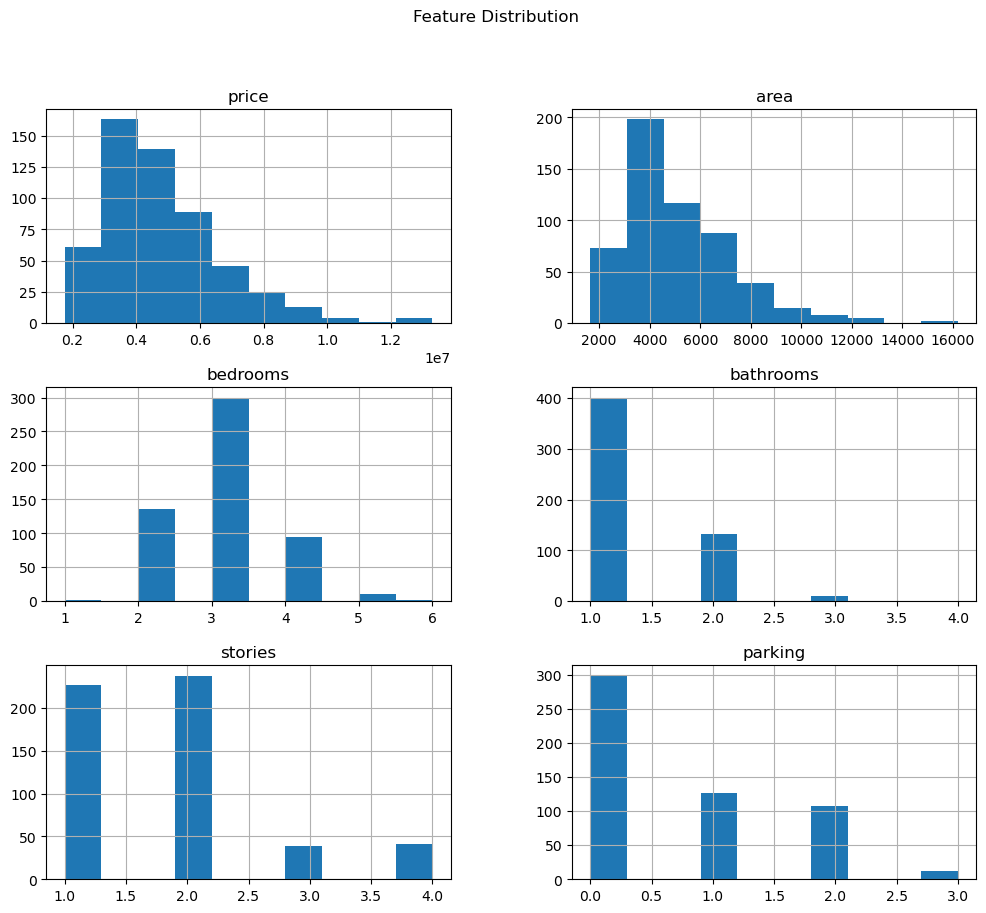

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 2  

Model Performance
R2 Scor

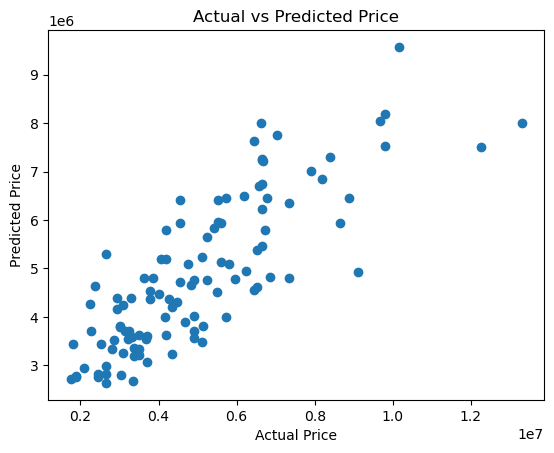

Model saved successfully

 Sample Prediction 


/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted House Price: 6386544.166697812

Pipeline Completed Successfully!


In [7]:
FILE_PATH = "Housing_Prices.csv"

# Dataset
def load_data(path):
    df = pd.read_csv(path)
    print("File loaded successfully")
    return df

# DatasetOverview
def data_overview(df):
    print("\nShape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicate Values:", df.duplicated().sum())
    print("\n Datatypes for Each column" , df.dtypes)
    print("\nSummary:\n", df.describe())
    print("Drop Nulls:" , df.dropna())
    print("Drop Duplicates", df.drop_duplicates())


# EDA
def perform_eda(df):

    # Price Distribution
    plt.figure(figsize=(8,5))
    sns.histplot(df['price'], bins=20, kde=True)
    plt.title("Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.show()
    
    # Area vs Price
    plt.figure(figsize=(8,5))
    plt.scatter(df['area'], df['price'])
    plt.title("Area vs Price")
    plt.xlabel("Area")
    plt.ylabel("Price")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(df['bedrooms'], bins=20, kde=True)
    plt.title("Bedrooms Distribution")
    plt.xlabel("Bedrooms")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(df['bathrooms'], bins=10, kde=False)
    plt.title("Bathrooms Distribution")
    plt.xlabel("Bathrooms")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(df['parking'], bins=5, kde=False)
    plt.title("Parking Distribution")
    plt.xlabel("Parking Spaces")
    plt.ylabel("Count")
    plt.show()

    sns.pairplot(df, hue='price')
    plt.show()

    df.hist(figsize = (12,10))
    plt.suptitle("Feature Distribution")
    plt.show()


# Preprocessing the data
def preprocess_data(df):

    
    binary_cols = [
        'mainroad', 'guestroom', 'basement',
        'hotwaterheating', 'airconditioning', 'prefarea'
    ]

    for col in binary_cols:
        df[col] = df[col].map({'yes': 1, 'no': 0})

    # Furnishing status encoding
    df['furnishingstatus'] = df['furnishingstatus'].map({
        'furnished': 2,
        'semi-furnished': 1,
        'unfurnished': 0
    })

    print(df.head())

    return df


# Train Model
def train_model(df):

    df = preprocess_data(df)

    X = df.drop("price", axis=1)
    y = df["price"]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(x_train, y_train)

    return model, x_test, y_test


# Evaluate Model
def evaluate_model(model, x_test, y_test):

    y_pred = model.predict(x_test)

    print("\nModel Performance")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

    # Plot
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.title("Actual vs Predicted Price")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.show()


#  Save Model
def save_model(model):
    pickle.dump(model, open("house_model.pkl", "wb"))
    print("Model saved successfully")


# Prediction Function

def predict_sample(model):
    print("\n Sample Prediction ")

    # Example input (must match feature order)
    sample = [[3000, 3, 2, 2, 1, 1, 0, 1, 0, 1, 1, 2]]
    
    prediction = model.predict(sample)

    print("Predicted House Price:", prediction[0])


#  Main Pipeline
def main():

    print("Starting Housing ML Pipeline")

    df = load_data(FILE_PATH)

    data_overview(df)

    perform_eda(df)

    model, x_test, y_test = train_model(df)

    evaluate_model(model, x_test, y_test)

    save_model(model)

    predict_sample(model)

    print("\nPipeline Completed Successfully!")


if __name__ == "__main__":
    main()